## Group 3 405-01 Data Science project

The project was divided up amongst the group. Joseph was assigned stage 2, Numrata stage 3, and Javier stage 4. Together we completed Stage 5.

Our project used the carrer recommendation data set found at link https://www.kaggle.com/datasets/ahsanneural/career-path-recommendations-dataset?resource=download

First we did data cleaning, then exploratory data analysis, then we did statistical analysis, and final was modeling using decision trees and random forest.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report




##Exploratory Data Analysis

In [3]:
df = pd.read_excel("careerdata.xlsx")
df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [4]:
# This cell displays basic information about the dataset (shape, types, summary)
df.shape
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Education Level     5000 non-null   str  
 1   Specialization      5000 non-null   str  
 2   Skills              5000 non-null   str  
 3   Certifications      4404 non-null   str  
 4   CGPA/Percentage     5000 non-null   int64
 5   Recommended Career  5000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 234.5 KB


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
count,5000,5000,5000,4404,5000.000000,5000
unique,5,8,757,7,NaN,12
top,Master's,Engineering,Accounting,Mental Health Basics,NaN,Clerk
freq,1028,668,204,674,NaN,432
mean,NaN,NaN,NaN,NaN,77.479800,NaN
std,NaN,NaN,NaN,NaN,10.396288,NaN
min,NaN,NaN,NaN,NaN,60.000000,NaN
25%,NaN,NaN,NaN,NaN,68.000000,NaN
50%,NaN,NaN,NaN,NaN,77.000000,NaN
75%,NaN,NaN,NaN,NaN,87.000000,NaN


In [5]:
# This cell checks for missing values in each column
df.isnull().sum()

Education Level         0
Specialization          0
Skills                  0
Certifications        596
CGPA/Percentage         0
Recommended Career      0
dtype: int64

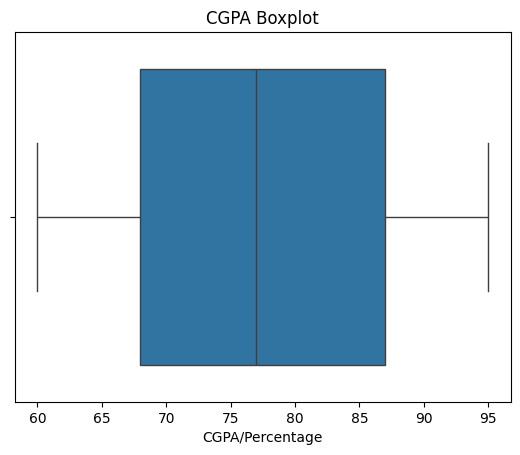

In [6]:
# This cell visualizes outliers in CGPA using a boxplot
sns.boxplot(x=df['CGPA/Percentage'])
plt.title("CGPA Boxplot")
plt.show()

In [7]:
# This cell calculates average CGPA for each recommended career
df.groupby('Recommended Career')['CGPA/Percentage'].mean()

Recommended Career
Business Analyst       77.777215
Clerk                  77.199074
Data Entry Operator    77.237288
Financial Analyst      77.230024
Junior Accountant      77.210654
ML Engineer            77.512821
Marketing Executive    78.564815
Professor              77.813268
Research Scientist     77.451074
Sales Assistant        77.898305
School Counselor       77.081535
Software Engineer      76.772182
Name: CGPA/Percentage, dtype: float64

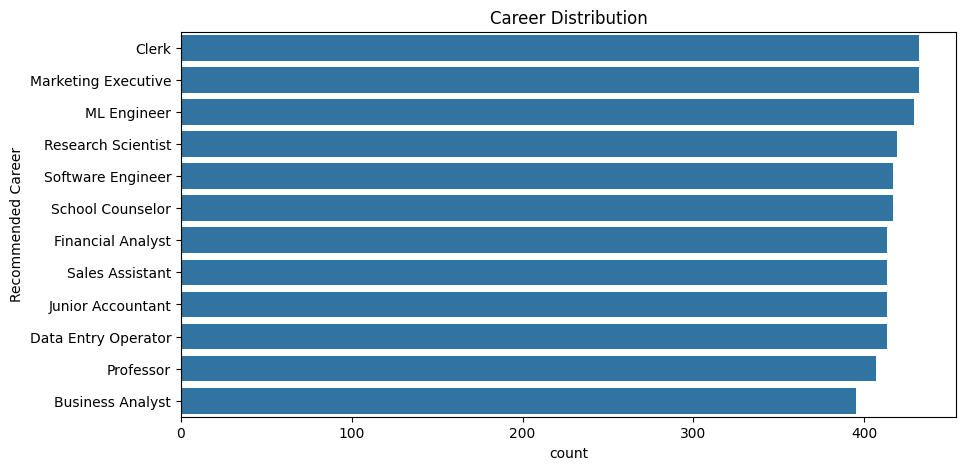

In [8]:
# This cell visualizes the distribution of recommended careers
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Recommended Career', order=df['Recommended Career'].value_counts().index)
plt.title("Career Distribution")
plt.show()

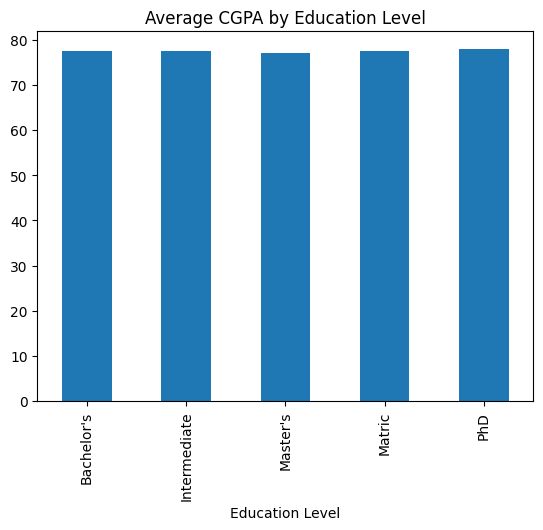

In [9]:
# This cell shows average CGPA by education level using a bar chart
df.groupby('Education Level')['CGPA/Percentage'].mean().plot(kind='bar')
plt.title("Average CGPA by Education Level")
plt.show()

## Statistical Analysis

In [10]:
data = pd.read_excel('careerdata.xlsx')

In [11]:
# T-Test for Comparing Means of Two Groups
group1 = data[data["Recommended Career"] == "Software Engineer"]["CGPA/Percentage"]
group2 = data[data["Recommended Career"] == "Clerk"]["CGPA/Percentage"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.6015562346279915
P-value: 0.5476311241831192


Software Engineer Mean: 76.77
Clerk Mean: 77.20


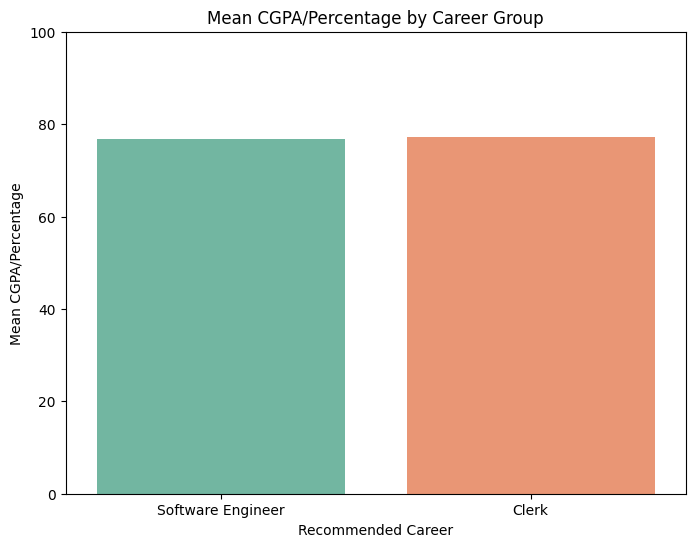

In [12]:
# Bar Graph with mean for both groups see difference before t-test
engineer_mean = data[data["Recommended Career"] == "Software Engineer"]["CGPA/Percentage"].mean()
clerk_mean = data[data["Recommended Career"] == "Clerk"]["CGPA/Percentage"].mean()
careers = ["Software Engineer", "Clerk"]
means = [engineer_mean, clerk_mean]
print(f"Software Engineer Mean: {engineer_mean:.2f}")
print(f"Clerk Mean: {clerk_mean:.2f}")

plt.figure(figsize=(8, 6))
sns.barplot(x=careers, y=means, hue=careers, palette="Set2", legend=False)
plt.ylabel("Mean CGPA/Percentage")
plt.xlabel("Recommended Career")
plt.title("Mean CGPA/Percentage by Career Group")
plt.ylim(0, 100)
plt.show()

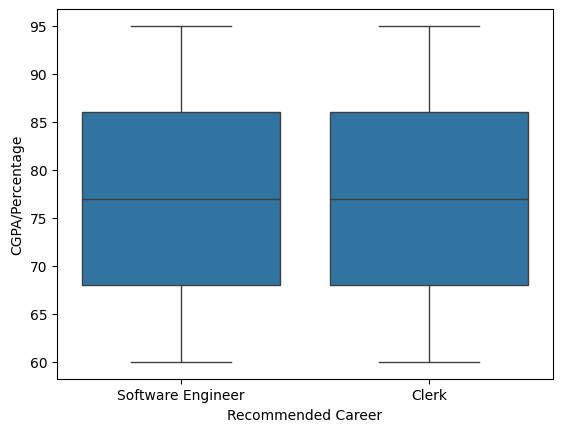

In [13]:
# Box Plot to visualize distribution and outliers
filtered_data = data[data["Recommended Career"].isin(["Software Engineer","Clerk"])]
sns.boxplot(x="Recommended Career", y="CGPA/Percentage", data=filtered_data)
plt.show()

Using a T-test to compare mean CGPA/Percentage between "Software Engineer" and "Clerk" career groups. The null hypothesis states that the mean CGPA/Percentage is the same for both groups, and the alternate hypothesis states that the means are different. Our P-value of 0.5476311241831193 is greater than 0.05, telling us that we failed to reject the null hypothesis. There is not enough evidence to support a difference in mean CGPA/Percentage between the two categories choosen. The mean average of both categories are similar. 

In [14]:
# Chi-Square Test of Independence

# Contingency table of Specilization vs Recommended Career (Degree of freedom 1)
table = pd.crosstab(data["Specialization"], data["Recommended Career"])

# Chi-square test to test if the 2 categories are related
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 84.93879861861754
p-value: 0.2507014727049615
Degrees of Freedom: 77


Using Chi-Squared test of independence to compare "Specilizatoin" and "Recommended Career". Null hypothesis(P-value ≤ 0.05) states that the variables are independent and alternate hypothesis (P-value > 0.05) state that there is a relation. Our P-value of 0.20192815982635112 is greater than .05 letting us know that we failed to reject the null hypothesis. There is not enough evidence to support a relation between our 2 categories. Chi-squared value by it'self can't be interepted accurately. 

#Data Modeling

Decided to go with Decision Tree and Random Forest to model data. First I'm going to one hot encode the features.

In [15]:
# turn each skill in skills into separate columns for one hot encoding
skills = data['Skills'].str.split(',').apply(lambda x: [skill.strip() for skill in x])
all_skills = skills.explode().unique()
skills_df = pd.DataFrame(0, index=data.index, columns=all_skills)
for idx, skill_list in enumerate(skills):
    for skill in skill_list:
        skills_df.loc[idx, skill] = 1
data = pd.concat([data, skills_df], axis=1)
data.drop('Skills', axis=1, inplace=True)

#one hot encoding for education level, specialization, certifications
data = pd.get_dummies(data, columns=['Education Level', 'Specialization', 'Certifications'], drop_first=True)

#use label encoding for recommended career

le = LabelEncoder()
data['Recommended Career'] = le.fit_transform(data['Recommended Career'])


print(data.columns)

Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Python', 'Marketing',
       'Education Level_Intermediate', 'Education Level_Master's',
       'Education Level_Matric', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP'],
      dtype='str')


In [16]:
# Split data
X = data.drop('Recommended Career', axis=1)
y = data['Recommended Career']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    # Get macro F1 directly
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

#append a result of a descision tree with no max depth
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
_, _, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
results.append(('No max depth', macro_f1))

# Best depth
best_depth, best_score = max(results, key=lambda x: x[1])
print(f"\nBest depth: {best_depth}")
print(f"Best Macro F1: {best_score:.4f}")


Depth 8 → Macro F1: 0.0696
Depth 9 → Macro F1: 0.0694
Depth 10 → Macro F1: 0.0828
Depth 11 → Macro F1: 0.0815
Depth 12 → Macro F1: 0.0846

Best depth: No max depth
Best Macro F1: 0.0891


The model was not able to learn any meaningful pattern from the data here.

In [17]:
#implement random forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
_, _, macro_f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='macro', zero_division=0
)
print(f"Random Forest Macro F1: {macro_f1_rf:.4f}")

Random Forest Macro F1: 0.0822


Random forest model is worse than decision tree, will need to simplify the data

In [18]:

data['Recommended Career'] = le.inverse_transform(data['Recommended Career'])

def map_career(career):
    if career in ['ML Engineer', 'Software Engineer', 'Data Entry Operator', 'Research Scientist']:
        return 'Tech'
    
    elif career in ['Business Analyst', 'Financial Analyst', 'Junior Accountant']:
        return 'Business/Finance'
    
    elif career in ['Marketing Executive', 'Sales Assistant']:
        return 'Marketing/Sales'
    
    elif career in ['Professor', 'School Counselor']:
        return 'Education'
    
    elif career in ['Clerk']:
        return 'Admin'
    
    else:
        return 'Other'  

# Apply grouping
data['Recommended Career'] = data['Recommended Career'].apply(map_career)



# Encode
le = LabelEncoder()
data['Recommended Career'] = le.fit_transform(data['Recommended Career'])

# Verify
print(le.classes_)

['Admin' 'Business/Finance' 'Education' 'Marketing/Sales' 'Tech']


This will decrease the amount of classes the model has to predict, making it more likely to be accurate

In [19]:
X = data.drop('Recommended Career', axis=1)
y = data['Recommended Career']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

# Test depths 8–12
for depth in range(8, 13):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

# Test no max depth
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

_, _, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
results.append(("No max depth", macro_f1))
print(f"No max depth → Macro F1: {macro_f1:.4f}")

# Pick best model setting
best_depth, best_score = max(results, key=lambda x: x[1])

print(f"\nBest depth: {best_depth}")
print(f"Best Macro F1: {best_score:.4f}")

#print the classification report for the best model
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42) if best_depth != 'No max depth' else DecisionTreeClassifier(random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Depth 8 → Macro F1: 0.1454
Depth 9 → Macro F1: 0.1508
Depth 10 → Macro F1: 0.1529
Depth 11 → Macro F1: 0.1639
Depth 12 → Macro F1: 0.1843
No max depth → Macro F1: 0.2054

Best depth: No max depth
Best Macro F1: 0.2054
                  precision    recall  f1-score   support

           Admin       0.06      0.07      0.06        85
Business/Finance       0.23      0.23      0.23       238
       Education       0.19      0.17      0.18       174
 Marketing/Sales       0.23      0.19      0.21       184
            Tech       0.34      0.36      0.35       319

        accuracy                           0.24      1000
       macro avg       0.21      0.20      0.21      1000
    weighted avg       0.24      0.24      0.24      1000



Got a 12% increase in accuracy for predicting up to 20% nowfor most classes, but thats due to the amount of classes being shrunk to 5. Admin has the worst precision at .06 and tech has the best at .34. Currently the model is not better than just randomly guessing the class so it hasn't learned a pattern from the data.

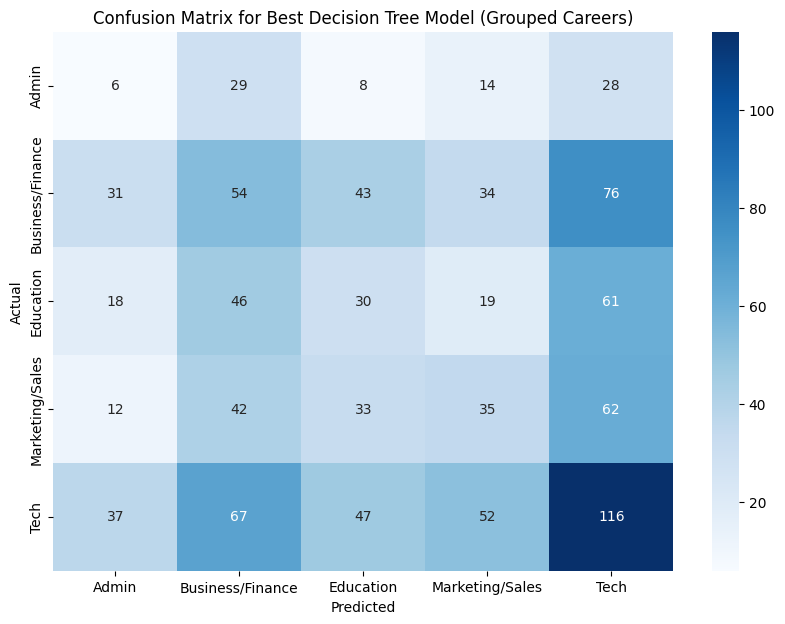

In [20]:
# plot confusion matrix for best model
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42) if best_depth != 'No max depth' else DecisionTreeClassifier(random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Best Decision Tree Model (Grouped Careers)')
plt.show()

Going to try to exclude certain features to see if I can get a better result

In [21]:


#combine intermediate and matric columns into highschool column
data['Education Level_High School'] = data['Education Level_Intermediate'] | data['Education Level_Matric']
data.drop(['Education Level_Intermediate', 'Education Level_Matric'], axis=1, inplace=True)
print(data.columns)

# add bachelors degree column
data['Education Level_Bachelors'] = (
    (data['Education Level_High School'] == 0) &
    (data["Education Level_Master's"] == 0) &
    (data['Education Level_PhD'] == 0)
).astype(int)

skills = [
    'Counseling', 'MS Office', 'Machine Learning', 'Accounting',
    'SQL', 'Data Analysis', 'Communication', 'Financial Analysis',
    'Python', 'Marketing'
]
# label skils with prefix "skills_" to make it easier for selection 
data.rename(columns={col: f"Skills_{col}" for col in skills}, inplace=True)
print(data.columns)

Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Python', 'Marketing',
       'Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP',
       'Education Level_High School'],
      dtype='str')
Index(['CGPA/Percentage', 'Recommended Career', 'Skills_Counseling',
       'Skills_MS Office', 'Skills_Machine Learning', 'Skills_Accounting',
       'Skills_SQL', 'Skills_Data Analysis', 'Skills_Communication',
     

In [22]:
# use only degree, certifications, and specialization to predict recommended career with decision tree
feature_cols = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_') or col.startswith('Certifications_')
]

X = data[feature_cols]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

Index(['Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP',
       'Education Level_High School', 'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1620
Depth 9 → Macro F1: 0.1873
Depth 10 → Macro F1: 0.1655
Depth 11 → Macro F1: 0.1797
Depth 12 → Macro F1: 0.1656


In [23]:
# use only degree and specialization to predict recommended career with decision tree
feature_cols1 = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_')
]

X = data[feature_cols1]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

Index(['Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Education Level_High School',
       'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1538
Depth 9 → Macro F1: 0.1645
Depth 10 → Macro F1: 0.1674
Depth 11 → Macro F1: 0.1674
Depth 12 → Macro F1: 0.1674


In [24]:
# use only degree and specialization and skills to predict recommended career with decision tree
feature_cols = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_') or col.startswith('Skills_')
]

X = data[feature_cols]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

Index(['Skills_Counseling', 'Skills_MS Office', 'Skills_Machine Learning',
       'Skills_Accounting', 'Skills_SQL', 'Skills_Data Analysis',
       'Skills_Communication', 'Skills_Financial Analysis', 'Skills_Python',
       'Skills_Marketing', 'Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Education Level_High School',
       'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1572
Depth 9 → Macro F1: 0.1677
Depth 10 → Macro F1: 0.1666
Depth 11 → Macro F1: 0.1808
Depth 12 → Macro F1: 0.1760


Couldn't find any combination or grouping of features to get a accuracy result that was better than random. Could be because of the data set being synthetic and that the dataset is just random. No strong relations between different categories. CGPA were similar over all the different Education Level. Data/column did not show any strong pattern or relation to the other categories. Couldn’t not do proper comparisons since all the data are categorical besides the CGPA
